In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving shop data.csv to shop data.csv


In [5]:
df=pd.read_csv('shop data.csv')
df

,age,income,gender,m_status,buys
0,<25,high,male,single,no
1,<25,high,male,married,no
2,25-35,high,male,single,yes
3,>35,medium,male,single,yes
4,>35,low,female,single,yes
5,>35,low,female,single,no
6,25-35,low,female,married,yes
7,<25,medium,male,married,no
8,<25,low,female,single,yes
9,>35,medium,female,married,yes


In [6]:
x=df.drop('buys',axis=1)
x

,age,income,gender,m_status
0,<25,high,male,single
1,<25,high,male,married
2,25-35,high,male,single
3,>35,medium,male,single
4,>35,low,female,single
5,>35,low,female,single
6,25-35,low,female,married
7,<25,medium,male,married
8,<25,low,female,single
9,>35,medium,female,married


In [7]:
y=df.buys
y


,buys
0,no
1,no
2,yes
3,yes
4,yes
5,no
6,yes
7,no
8,yes
9,yes


In [8]:
from sklearn.preprocessing import LabelEncoder
le_x=LabelEncoder()
x=x.apply(le_x.fit_transform)
x

,age,income,gender,m_status
0,1,0,1,1
1,1,0,1,0
2,0,0,1,1
3,2,2,1,1
4,2,1,0,1
5,2,1,0,1
6,0,1,0,0
7,1,2,1,0
8,1,1,0,1
9,2,2,0,0


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=2)

In [10]:
x_train

,age,income,gender,m_status
10,1,2,0,1
9,2,2,0,0
4,2,1,0,1
5,2,1,0,1
16,2,2,1,0
1,1,0,1,0
2,0,0,1,1
7,1,2,1,0
18,0,2,0,0
17,1,0,0,1


In [11]:
x_test

,age,income,gender,m_status
12,0,0,0,1
0,1,0,1,1
14,1,0,1,1
6,0,1,0,0
19,0,0,1,1
20,2,2,0,0
3,2,2,1,1


In [12]:
y_train

,buys
10,yes
9,yes
4,yes
5,no
16,yes
1,no
2,yes
7,no
18,yes
17,yes


In [13]:
y_test

,buys
12,yes
0,no
14,no
6,yes
19,yes
20,no
3,yes


In [14]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [22]:
y_predict=dtc.predict(x_test)
y_predict

array(['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes'], dtype=object)

In [25]:
y_test

,buys
12,yes
0,no
14,no
6,yes
19,yes
20,no
3,yes


In [24]:
score=dtc.score(x_test,y_test)
score

0.5714285714285714

In [30]:
from sklearn.model_selection import cross_val_score
result=cross_val_score(DecisionTreeClassifier(),x,y,cv=5)
result.mean()


np.float64(0.54)

In [34]:
from sklearn.linear_model import LogisticRegression
result = cross_val_score(LogisticRegression(), x, y, cv=5)
result

array([0.4 , 0.6 , 0.75, 0.5 , 0.75])

In [35]:
result.mean()

np.float64(0.6)

In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.5, 0. , 1. , 1. ],
       [0.5, 0. , 1. , 0. ],
       [0. , 0. , 1. , 1. ],
       [1. , 1. , 1. , 1. ],
       [1. , 0.5, 0. , 1. ],
       [1. , 0.5, 0. , 1. ],
       [0. , 0.5, 0. , 0. ],
       [0.5, 1. , 1. , 0. ],
       [0.5, 0.5, 0. , 1. ],
       [1. , 1. , 0. , 0. ],
       [0.5, 1. , 0. , 1. ],
       [0. , 1. , 1. , 0. ],
       [0. , 0. , 0. , 1. ],
       [1. , 1. , 1. , 0. ],
       [0.5, 0. , 1. , 1. ],
       [0.5, 0. , 0. , 0. ],
       [1. , 1. , 1. , 0. ],
       [0.5, 0. , 0. , 1. ],
       [0. , 1. , 0. , 0. ],
       [0. , 0. , 1. , 1. ],
       [1. , 1. , 0. , 0. ],
       [0.5, 0.5, 1. , 1. ]])

In [37]:
from sklearn.neighbors import KNeighborsClassifier
result = cross_val_score(KNeighborsClassifier(n_neighbors=3), x_scaled, y, cv=5)
result

array([0.8 , 0.4 , 0.75, 0.5 , 0.25])

In [38]:
result.mean()

np.float64(0.54)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

              precision    recall  f1-score   support

          no       0.00      0.00      0.00         3
         yes       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7

[[0 3]
 [0 4]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
xinput = np.array([1,0,1,1])
y_predict = dtc.predict([xinput])
y_predict

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['yes'], dtype=object)

In [45]:
x.columns.tolist()

['age', 'income', 'gender', 'm_status']

[Text(0.5, 0.9, 'gender <= 0.5\ngini = 0.391\nsamples = 15\nvalue = [4, 11]'),
 Text(0.2, 0.7, 'age <= 1.5\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3, 0.5, 'm_status <= 0.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.3, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.8, 0.7, 'm_status <= 0.5\ngini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'age <= 0.5\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.6, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.3, 'age <= 1.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.9, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.9, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]')]

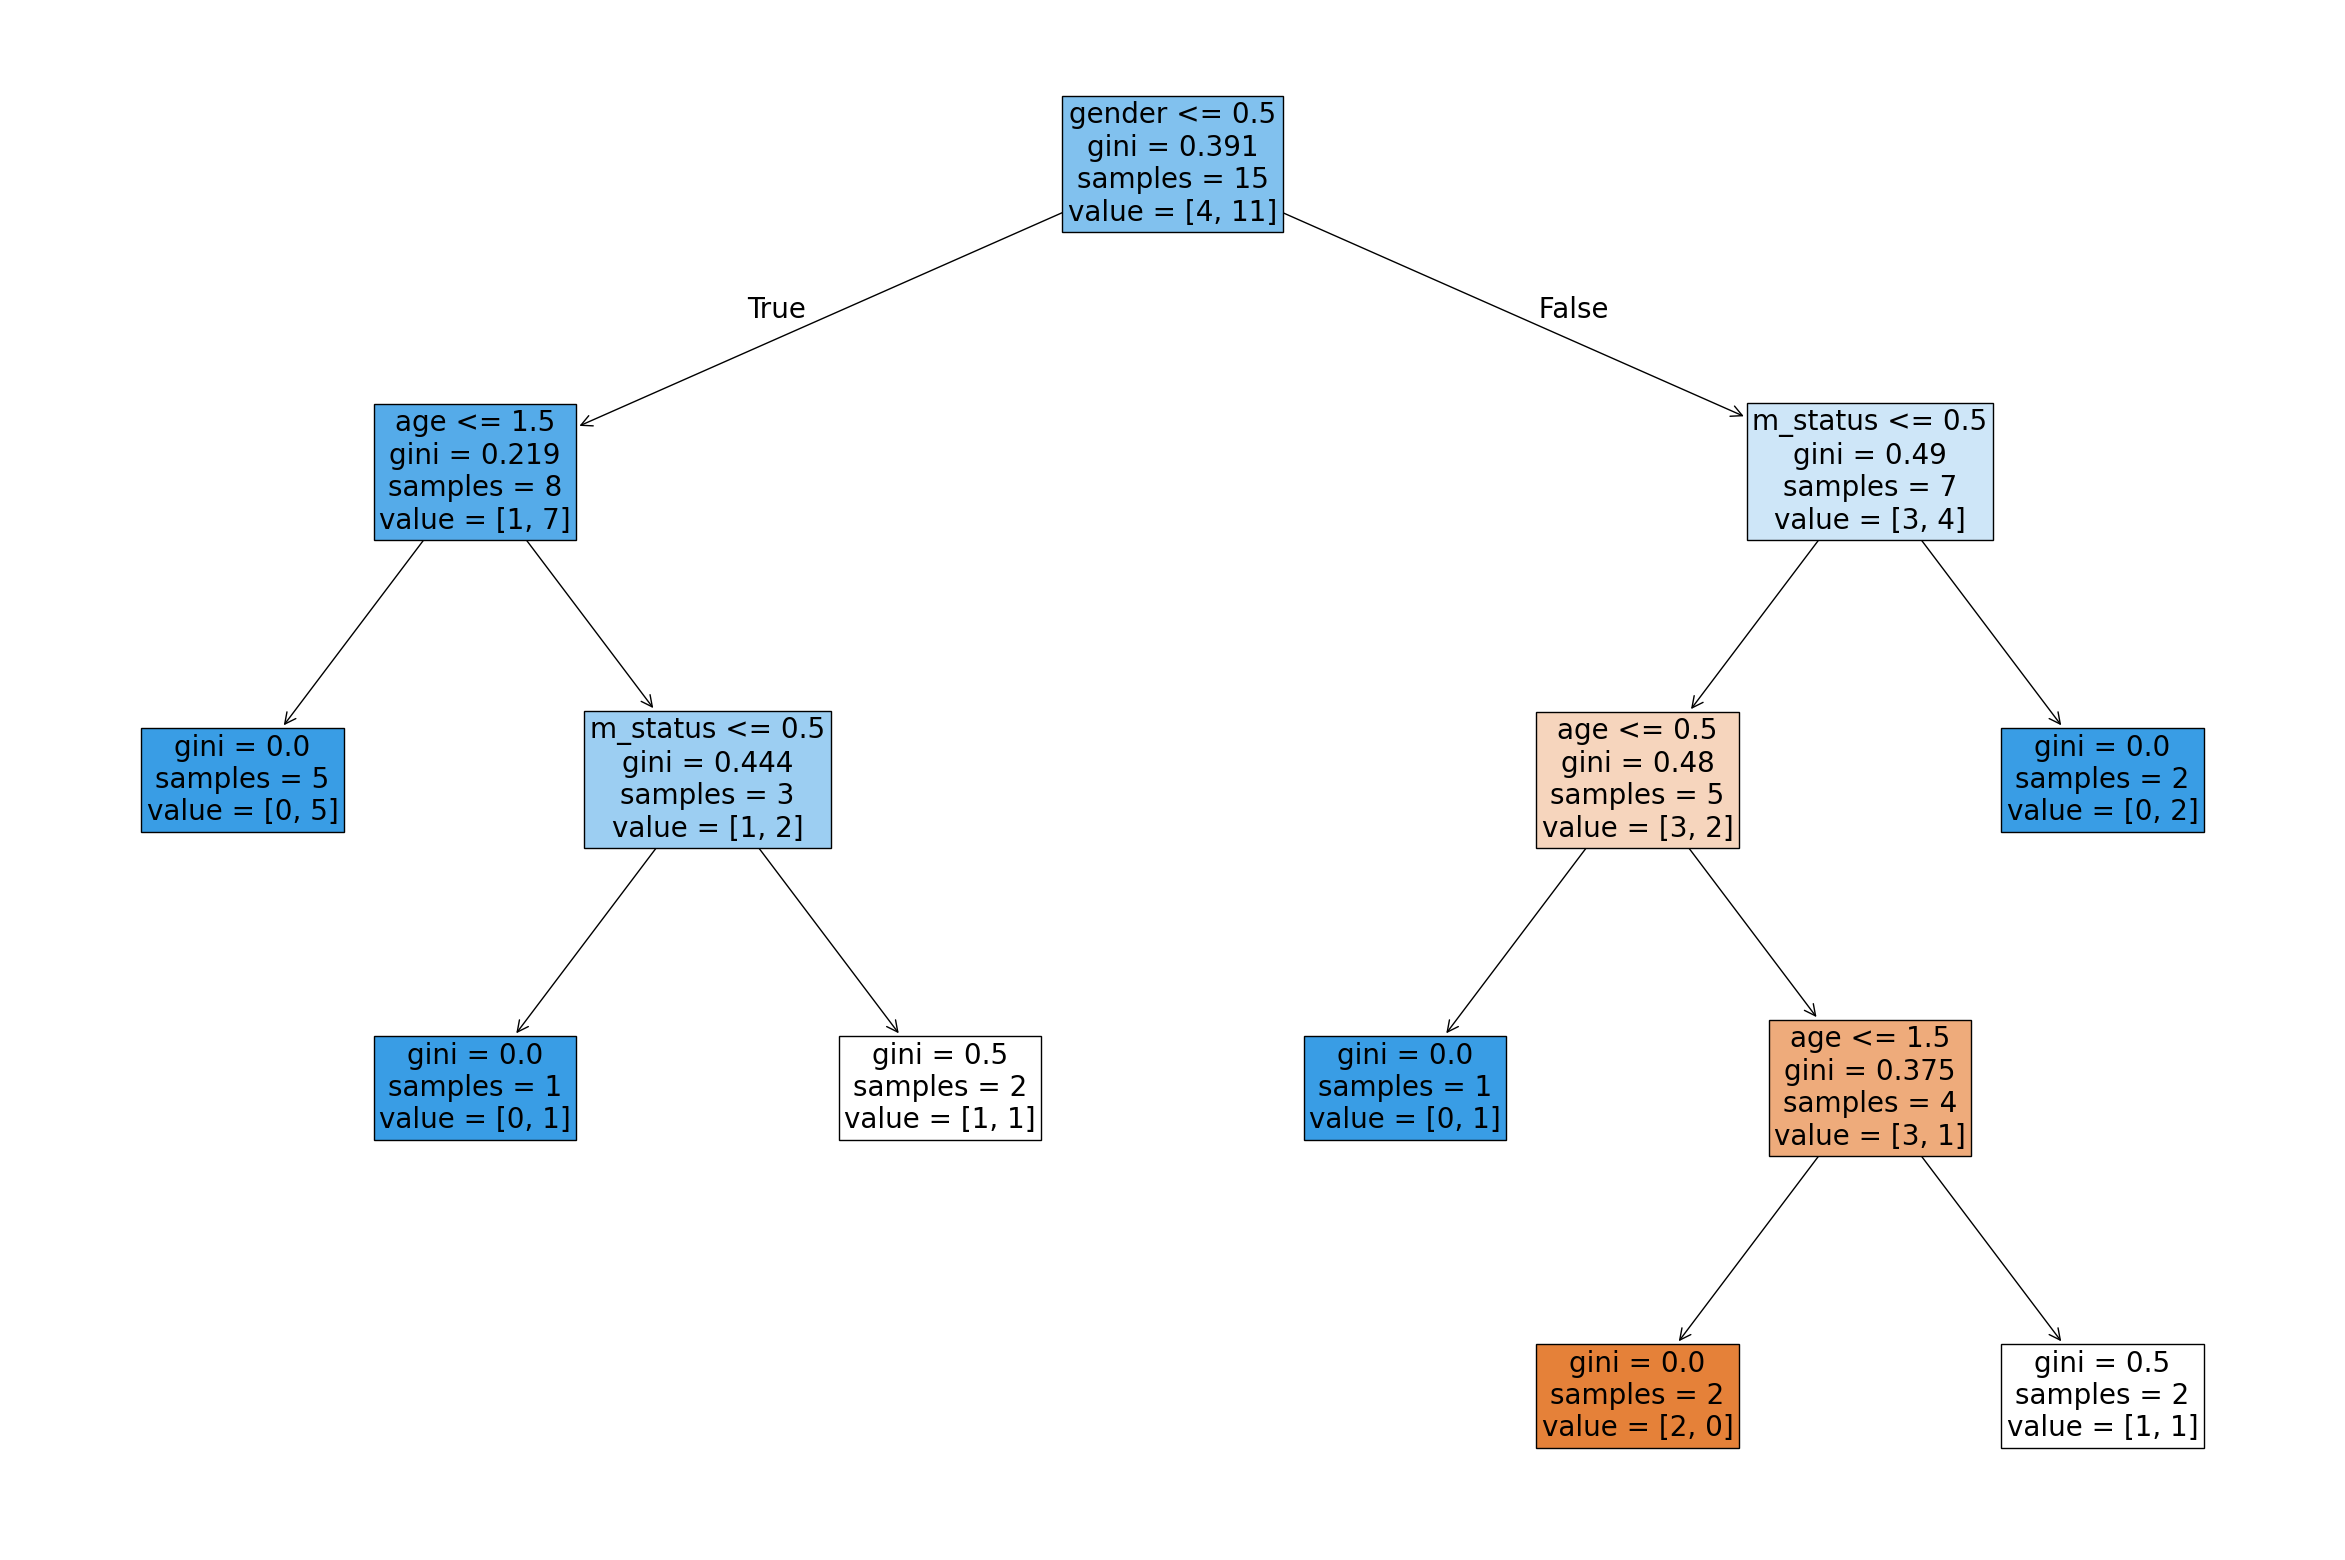

In [47]:
from sklearn import tree
from matplotlib import pyplot as plt
fig=plt.figure(figsize=(30,20))
tree.plot_tree(dtc, feature_names=x.columns.tolist(), filled=True, fontsize=20)